In [4]:
## MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **1. INSTALL AND IMPORT NECESSARY LIBRARIES**

In [5]:
!pip install albumentations
!pip install timm
!pip install --upgrade opencv-contrib-python

In [6]:
import re
import os

from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split   # Split datasets into training and testing sets
import random                                          # Generate random numbers or perform random selections
from typing import Tuple, Dict, Any, List, Optional              # Type hinting for function signatures (improves readability)

import torch                          # Main PyTorch library for tensors and deep learning
import torch.utils.data               # Utilities for creating and managing datasets and data loaders
from torch.utils.data import Dataset, DataLoader  # Base classes for custom datasets and batching
from torchvision.ops import box_convert                      # Convert bounding box formats (e.g., xywh <-> xyxy)
import torchvision                                            # Computer vision models and datasets
from torchvision.transforms import functional as TF           # Image transformations (alias TF for convenience)
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2  # Pretrained Mask R-CNN model (v2)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor  # Predictor head for Faster R-CNN
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor    # Predictor head for Mask R-CNN
import torchvision.transforms.functional as F                 # Functional API for image transforms (alias F)

from PIL import Image                      # Read and manipulate image files (Pillow library)
import cv2                                             # OpenCV for image processing and computer vision tasks

from xml.dom import minidom                 # Parse and extract data from XML files (DOM interface)
from xml.etree import ElementTree           # Lightweight XML parsing and tree navigation
import csv                                  # Read and write CSV files

import pandas as pd                         # Data manipulation and analysis (DataFrames, CSV handling)
from sklearn.preprocessing import LabelEncoder  # Encode categorical labels into numerical form

import os                                    # File and directory operations
import json                                  # Read and write JSON files
import time                                  # Time-related functions (e.g., delays, timestamps)
from pathlib import Path                     # Object-oriented filesystem paths

import numpy as np                            # Numerical operations on arrays and matrices
import matplotlib.pyplot as plt               # Plotting and visualisation
from matplotlib.patches import Rectangle      # Draw rectangular shapes (e.g., bounding boxes)

try:
    from tqdm.auto import tqdm                # Auto-detect environment (console/Jupyter) for tqdm
except Exception:
    tqdm = None                               # Fallback in case tqdm.auto is unavailable



# **2. LOAD DATA**

In [ ]:
pattern = r"(\d+)\.jpg$"
img_numbers=[]

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/data/annotated-images'):
    for filename in filenames:
        match = re.search(pattern,filename,re.IGNORECASE)

        if match:
            number = match.group(1)
            img_numbers.append(number)

img_numbers.sort()

In [ ]:
img_numbers

['1',
 '10',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '11',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '12',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '13',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138',
 '139',
 '14',
 '140',
 '141',
 '142',
 '143',
 '144',
 '145',
 '146',
 '147',
 '148',
 '149',
 '15',
 '150',
 '151',
 '152',
 '153',
 '154',
 '155',
 '156',
 '157',
 '158',
 '159',
 '16',
 '160',
 '161',
 '162',
 '163',
 '164',
 '165',
 '166',
 '167',
 '168',
 '169',
 '17',
 '170',
 '171',
 '172',
 '173',
 '174',
 '175',
 '176',
 '177',
 '178',
 '179',
 '18',
 '180',
 '181',
 '182',
 '183',
 '184',
 '185',
 '186',
 '187',
 '188',
 '189',
 '19',
 '190',
 '191',
 '192',
 '193',
 '194',
 '195',
 '196',
 '197',
 '198',
 '199',
 '2',
 '20',
 '200',
 '201',
 '202',
 '203',
 '204',
 '205',
 '206',
 '207',
 '208',
 '209',
 '21',
 '210',
 '211',
 '212',


Extract multiple bounding boxes from XML file

In [ ]:
def extract_multiple_bboxes(xml_path, image_path, base_dir):
    """
    Parses an XML file and returns a list of bounding boxes and image metadata.

    Parameters:
        xml_path (str): Full path to the XML annotation file
        image_path (str): Path to the image file
        base_dir (str): Base directory where the image files are stored

    Returns:
        image_full_path (str): Full path to the image
        width (int): Width of the image
        height (int): Height of the image
        boxes (list of tuples): List of bounding boxes (x1, y1, x2, y2)
    """
    # Parse the XML annotation file
    xml_doc = minidom.parse(xml_path)

    # Read image to get dimensions
    height, width = cv2.imread(image_path).shape[:2]

    # Extract filename and construct full image path
    filename_tag = xml_doc.getElementsByTagName('filename')[0]
    filename = filename_tag.firstChild.data
    image_full_path = os.path.join(base_dir, filename)

    # Extract all bounding boxes from <object> tags
    objects = xml_doc.getElementsByTagName('object')
    boxes = []

    for obj in objects:
        xmin = int(obj.getElementsByTagName('xmin')[0].firstChild.data)
        ymin = int(obj.getElementsByTagName('ymin')[0].firstChild.data)
        xmax = int(obj.getElementsByTagName('xmax')[0].firstChild.data)
        ymax = int(obj.getElementsByTagName('ymax')[0].firstChild.data)

        boxes.append((xmin, ymin, xmax, ymax))

    return image_full_path, width, height, boxes


# **3. DATASET**

In [7]:
# Function to convert XML files to CSV
def xml_to_csv(data_dir):
    xml_list={'filename':[],
              'width':[],
              'height':[],
              'xmin':[],
              'ymin':[],
              'xmax':[],
              'ymax':[]
              }

  # Loop over each of the image and its label
    for i in img_numbers:

        mat = f"img-{i}.xml"
        image_file = f"img-{i}.jpg"

      # Full mat path
        mat_path = os.path.join(data_dir, mat)

      # Full path Image
        img_path = os.path.join(data_dir, image_file)

      # Get Attributes for each image
        filename, width, height, bbox = extract_multiple_bboxes(mat_path, img_path,data_dir)
        iter=1
        for xmin,	ymin,	xmax,	ymax in bbox:
          name=number = re.search(r'img-(\d+)\.jpg', filename).group(1)

          xml_list['filename'].append(str(f'{name}-0{iter}'))
          xml_list['width'].append(width)
          xml_list['height'].append(height)
          xml_list['xmin'].append(xmin)
          xml_list['ymin'].append(ymin)
          xml_list['xmax'].append(xmax)
          xml_list['ymax'].append(ymax)
          iter+=1

  # Create the DataFrame from mat_list
    xml_df = pd.DataFrame(xml_list)

  # Return the dataframe
    return xml_df

In [34]:
def parse_voc_xml(xml_path: str):
    tree = ElementTree.parse(xml_path)
    root = tree.getroot()
    w = int(root.findtext(".//size/width"))
    h = int(root.findtext(".//size/height"))
    boxes, labels = [], []
    for obj in root.findall(".//object"):
        name = obj.findtext("name").strip().lower()
        if name not in NAME_TO_ID:
            continue
        xmin = int(float(obj.findtext("./bndbox/xmin"))); ymin = int(float(obj.findtext("./bndbox/ymin")))
        xmax = int(float(obj.findtext("./bndbox/xmax"))); ymax = int(float(obj.findtext("./bndbox/ymax")))
        xmin = max(0, min(xmin, w - 1)); ymin = max(0, min(ymin, h - 1))
        xmax = max(xmin + 1, min(xmax, w)); ymax = max(ymin + 1, min(ymax, h))
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(NAME_TO_ID[name])
    return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64), (h, w)

In [ ]:
DATA_DIR = "/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/data/annotated-images"
# convert all the xml files to a Pandas DataFrame
labels_df = xml_to_csv(data_dir=DATA_DIR)

# Saving the Pandas DataFrame as CSV File
labels_df.to_csv(('dataset.csv'), index=None)

In [ ]:
labels_df

,filename,width,height,xmin,ymin,xmax,ymax
0,1-01,720,720,213,240,525,378
1,10-01,720,720,285,214,444,355
2,100-01,720,720,235,272,434,388
3,101-01,720,720,228,303,394,432
4,101-02,720,720,397,317,554,411
...,...,...,...,...,...,...,...
1735,98-01,720,720,505,44,585,101
1736,98-02,720,720,234,243,492,426
1737,98-03,720,720,547,272,720,394
1738,98-04,720,720,653,345,720,420


In [ ]:
def check_image(img_no):
  rectangles = []
  i=1
  ind=int(labels_df.index[labels_df['filename'] == f'{img_no}-01'][0])
  while True:
    if f'{img_no}-0{i}' not in labels_df['filename'].values:
      break
    ind = labels_df.index[labels_df['filename'] == f'{img_no}-0{i}'][0]
    row = labels_df.iloc[ind]
    img = cv2.imread(f'/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/data/annotated-images/img-{img_no}.jpg')
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    pt1 = (row.xmin, row.ymin)
    pt2 = (row.xmax, row.ymax)

    rectangles.append((pt1,pt2))
    i+=1
    ind+=1

  for rect in rectangles:
    pt1, pt2 = rect
    cv2.rectangle(img, pt1, pt2, (255,0,0),2)
    plt.imshow(img)


In [ ]:
img_1=8 #input a number of your choice
img_2=102 #input a number of your choice

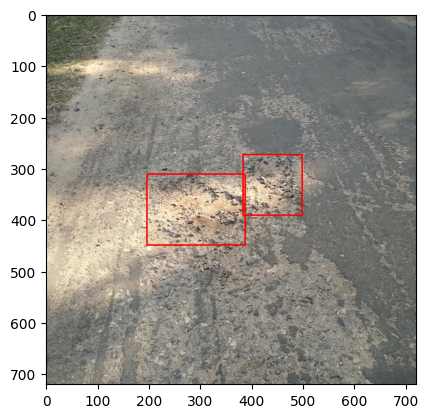

In [ ]:
check_image(img_1)

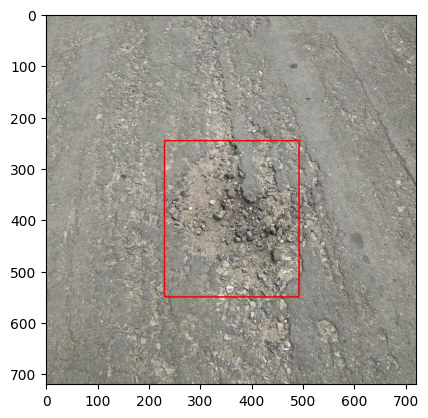

In [ ]:
check_image(img_2)

In [ ]:
train_df, valid_df = train_test_split(labels_df,test_size=0.10,random_state=42)

In [ ]:
train_df

,filename,width,height,xmin,ymin,xmax,ymax
1226,551-03,527,300,398,160,434,182
1667,663-05,335,300,224,127,250,144
1715,86-02,720,720,357,378,514,464
59,127-01,720,720,357,306,537,398
1182,535-03,449,300,119,72,171,97
...,...,...,...,...,...,...,...
1130,524-05,533,300,1,209,195,253
1294,566-03,438,300,240,120,278,147
860,444-06,458,300,244,219,380,300
1459,60-01,720,720,308,282,443,404


# **4. SET PARAMETERS - PREPARING FOR THE MODELLING PROCEDURE**



In [23]:
# Data roots
DATA_ROOT   = "/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/data/dataset_structured"
img_numbers=128
SPLIT_THRESHOLD = int(img_numbers * 0.8)


# Classes
CLASS_NAMES = ["__background__", "pothole"]
NAME_TO_ID = {n: i for i, n in enumerate(CLASS_NAMES)}
ID_TO_NAME = {i: n for n, i in NAME_TO_ID.items()}

# Training hyperparameters
EPOCHS = 13
BATCH_SIZE = 2
NUM_WORKERS = 2
LR = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
STEP_SIZE = 8
GAMMA = 0.1

# Checkpointing & resume
OUTPUT_DIR = Path("/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_EVERY = 2              # save every N epochs
MAX_VAL_BATCHES = 4
AUTO_RESUME = True
RESUME_PATH = ""

# Progress bar toggles
SHOW_EPOCH_BAR = True             # per-epoch percentage
SHOW_OVERALL_BAR = True           # overall percentage across all epochs
PREVIEW_EVERY = 0
SCORE_THRESH = 0.5

# **5. MODELLING**

In [24]:
class PotholeCDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        root_dir: str,
        is_train: bool = True,
        split_threshold: int = 532,
        transforms=None,
        require_xml: bool = True,
        numeric_only: bool = True,  # ignored when split_threshold=None
    ):
        self.root = Path(root_dir)
        self.img_dir = self.root / "images"
        self.ann_dir = self.root / "annots"
        self.is_train = is_train
        self.split_threshold = split_threshold
        self.transforms = transforms
        self.require_xml = require_xml
        self.numeric_only = numeric_only

        if not self.img_dir.exists() or not self.ann_dir.exists():
            raise FileNotFoundError(f"Expecting {self.img_dir} and {self.ann_dir}")

        self.ids = []
        for p in sorted(self.img_dir.iterdir()):
            if p.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                continue
            stem = p.stem

            if self.split_threshold is None:
                if self.require_xml and not (self.ann_dir / f"{stem}.xml").exists():
                    continue
                self.ids.append(stem)
                continue

            try:
                num = int(stem)
            except ValueError:
                if self.numeric_only:
                    continue
                num = None

            if self.is_train and num is not None and num >= self.split_threshold:
                continue
            if (not self.is_train) and num is not None and num < self.split_threshold:
                continue

            if self.require_xml and not (self.ann_dir / f"{stem}.xml").exists():
                continue

            self.ids.append(stem)

        if len(self.ids) == 0:
            raise RuntimeError(
                f"No images found for is_train={is_train} at {root_dir}.\n"
                f"- If using separate train/val, set split_threshold=None in dataset init.\n"
                f"- Or adjust SPLIT_THRESHOLD / ensure numeric filenames + matching XML."
            )

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        stem = self.ids[idx]
        img_path = None
        for sfx in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
            p = self.img_dir / f"{stem}{sfx}"
            if p.exists():
                img_path = p; break
        if img_path is None:
            raise FileNotFoundError(f"No image file found for stem {stem} in {self.img_dir}")

        xml_path = self.ann_dir / f"{stem}.xml"
        if self.require_xml and not xml_path.exists():
            raise FileNotFoundError(f"Missing XML: {xml_path}")

        img = Image.open(img_path).convert("RGB")
        boxes, labels, (h, w) = parse_voc_xml(str(xml_path))

        if boxes.shape[0] == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            masks_t  = torch.zeros((0, img.height, img.width), dtype=torch.uint8)
            area_t   = torch.zeros((0,), dtype=torch.float32)
            iscrowd_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t  = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)

            masks = np.zeros((boxes.shape[0], img.height, img.width), dtype=np.uint8)
            for i, (xmin, ymin, xmax, ymax) in enumerate(boxes.astype(int)):
                masks[i, ymin:ymax, xmin:xmax] = 1
            masks_t = torch.as_tensor(masks, dtype=torch.uint8)

            area_t   = (boxes_t[:, 3] - boxes_t[:, 1]) * (boxes_t[:, 2] - boxes_t[:, 0])
            iscrowd_t = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        image_id_val = int(stem) if stem.isdigit() else 0
        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "masks": masks_t,
            "image_id": torch.tensor([image_id_val], dtype=torch.int64),
            "area": area_t,
            "iscrowd": iscrowd_t,
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target


## **5.1 - TRANSFORMS**




In [25]:
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

class ToTensor:
    def __call__(self, image, target):
        return F.to_tensor(image), target

import torchvision.transforms.functional as F

class ResizeTo512:
    def __init__(self, size=512):
        self.size = size

    def __call__(self, image, target):
        # image is tensor (C, H, W) after ToTensor
        _, h, w = image.shape

        #  scale = 512
        if max(h, w) > self.size:      # downscale
            scale = self.size / max(h, w)
        elif max(h, w) < self.size:    # upscale
            scale = self.size / max(h, w)
        else:                          # already equal
            scale = 1.0

        new_h, new_w = int(round(h * scale)), int(round(w * scale))

        if scale != 1.0:
            image = F.resize(image, (new_h, new_w))

            if target["boxes"].numel() > 0:
                boxes = target["boxes"].clone()
                boxes[:, [0, 2]] = boxes[:, [0, 2]] * (new_w / w)
                boxes[:, [1, 3]] = boxes[:, [1, 3]] * (new_h / h)
                target["boxes"] = boxes

            if "masks" in target and target["masks"].numel() > 0:
                target["masks"] = F.resize(target["masks"], (new_h, new_w))

        # pad to make it 512×512 ---
        _, h, w = image.shape
        pad_h = self.size - h
        pad_w = self.size - w

        # pad format = (left, top, right, bottom)
        image = F.pad(image, (0, 0, pad_w, pad_h))

        if "masks" in target and target["masks"].numel() > 0:
            target["masks"] = F.pad(target["masks"], (0, 0, pad_w, pad_h))

        if target["boxes"].numel() > 0 and (pad_w > 0 or pad_h > 0):
            boxes = target["boxes"].clone()
            target["boxes"] = boxes

        return image, target

class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, image, target):
        if np.random.rand() < self.p:
            image = F.hflip(image)
            w = image.shape[-1]
            boxes = target["boxes"]
            if boxes.numel() > 0:
                x_min = w - boxes[:, 2]
                x_max = w - boxes[:, 0]
                boxes[:, 0] = x_min
                boxes[:, 2] = x_max
                target["boxes"] = boxes
            if "masks" in target and target["masks"].numel() > 0:
                target["masks"] = target["masks"].flip(-1)
        return image, target


def get_transforms(train=True):
    t = [ToTensor(), ResizeTo512(512)]
    if train:
        t.append(RandomHorizontalFlip(0.5))
    return Compose(t)

## **5.2 - MODEL BUILDER**

In [26]:

def get_model_instance_segmentation(num_classes: int):
    try:
        model = maskrcnn_resnet50_fpn_v2(weights="DEFAULT")
        print("[INFO] Loaded COCO-pretrained backbone weights.")
    except Exception as e:
        print("[WARN] Could not load pretrained weights:", e)
        model = maskrcnn_resnet50_fpn_v2(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model


## **5.3 - TRAINING UTILS**

In [27]:
def collate_fn(batch):
    return tuple(zip(*batch))

def _print_fallback(epoch, i, total, avg_loss):
    pct = int(100 * i / max(1, total))
    print(f"Epoch {epoch} [{pct:3d}%] avg_loss={avg_loss:.4f}", end="\r", flush=True)

def train_one_epoch(model, optimizer, data_loader, device, epoch, total_epochs=None, overall_pbar=None, print_freq=50):
    model.train()
    running = 0.0
    n = 0
    total = len(data_loader)
    iterator = data_loader

    if tqdm is not None and SHOW_EPOCH_BAR:
        desc = f"Epoch {epoch}" if total_epochs is None else f"Epoch {epoch}/{total_epochs}"
        iterator = tqdm(data_loader, total=total, desc=desc, leave=True)

    for i, (images, targets) in enumerate(iterator, 1):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running += losses.item()
        n += 1

        # Update progress display
        avg = running / n
        if tqdm is None or not SHOW_EPOCH_BAR:
            if (i % print_freq == 0) or (i == total):
                _print_fallback(epoch, i, total, avg)
        if overall_pbar is not None:
            overall_pbar.update(1)

    if tqdm is None or not SHOW_EPOCH_BAR:
        print()

    return running / max(1, n)

@torch.no_grad()
def validation_loss(model, data_loader, device, max_batches=None):
    model.train()
    total = 0.0
    n = 0
    for i, (images, targets) in enumerate(data_loader, 1):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        total += float(losses.item())
        n += 1
        if max_batches is not None and i >= max_batches:
            break
    model.eval()
    return total / max(1, n)

@torch.no_grad()
def preview_prediction(model, data_loader, device, score_thresh=0.5):
    model.eval()
    try:
        images, targets = next(iter(data_loader))
    except StopIteration:
        print("[WARN] No images in val loader to preview.")
        return
    images = [img.to(device) for img in images]
    outputs = model(images)
    show_prediction(images[0].cpu(), outputs[0], score_thresh=score_thresh, label_map={1: "POTHOLE"})

def show_prediction(image_tensor, output, score_thresh=0.5, label_map=None):
    if label_map is None:
        label_map = {1: "POTHOLE"}
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    boxes = output.get("boxes", torch.empty((0,4))).cpu().numpy()
    labels = output.get("labels", torch.empty((0,), dtype=torch.int64)).cpu().numpy()
    scores = output.get("scores", torch.empty((0,), dtype=torch.float32)).cpu().numpy()
    masks = output.get("masks", None)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    for i in range(len(boxes)):
        if i < len(scores) and scores[i] < score_thresh:
            continue
        x1, y1, x2, y2 = boxes[i].astype(int)
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))
        lbl = label_map.get(int(labels[i]), f"id_{int(labels[i])}") if i < len(labels) else "id_?"
        sc  = scores[i] if i < len(scores) else 1.0
        ax.text(x1, y1 - 3, f"{lbl} {sc:.2f}")
        if masks is not None and i < masks.shape[0]:
            m = (masks[i, 0].cpu().numpy() > 0.5).astype(np.uint8)
            ax.imshow(np.ma.masked_where(m == 0, m), alpha=0.4)
    ax.axis("off"); plt.tight_layout(); plt.show()

def plot_losses(history):
    epochs = [h["epoch"] for h in history]
    train_losses = [h["train_loss"] for h in history]
    val_losses = [h.get("val_loss", None) for h in history]
    plt.figure(figsize=(7,5))
    plt.plot(epochs, train_losses, label="train")
    if any(v is not None for v in val_losses):
        v = [x if x is not None else float('nan') for x in val_losses]
        plt.plot(epochs, v, label="val")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss vs Epoch")
    plt.show()


## **5.4 - BUILD DATASETS & DATALOADERS**

In [28]:

if SPLIT_THRESHOLD is not None:
    ds_train = PotholeCDataset(DATA_ROOT, is_train=True,  split_threshold=SPLIT_THRESHOLD, transforms=get_transforms(train=True))
    ds_val   = PotholeCDataset(DATA_ROOT, is_train=True, split_threshold=SPLIT_THRESHOLD, transforms=get_transforms(train=False))
else:
    ds_train = PotholeCDataset(TRAIN_ROOT, is_train=True,  split_threshold=None, transforms=get_transforms(train=True))
    ds_val   = PotholeCDataset(VAL_ROOT,   is_train=False, split_threshold=None, transforms=get_transforms(train=False))

print("Train images:", len(ds_train))
print("Val images:", len(ds_val))

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader   = DataLoader(ds_val,   batch_size=1,         shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)


Train images: 101
Val images: 101


### **Build Model**

In [30]:
device='cpu'
num_classes = len(CLASS_NAMES)
model = get_model_instance_segmentation(num_classes).to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

start_epoch = 1
history = []

def list_checkpoints(folder: Path):
    return sorted(folder.glob("*.pth"), key=lambda p: p.stat().st_mtime)

def load_checkpoint(path: Path):
    global start_epoch, history
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])
    lr_scheduler.load_state_dict(ckpt["sched_state"])
    history = ckpt.get("history", [])
    start_epoch = int(ckpt["epoch"]) + 1
    print(f"[INFO] Resumed from {path}, starting at epoch {start_epoch}.")

def auto_resume():
    cks = list_checkpoints(OUTPUT_DIR)
    if len(cks) == 0:
        print("[INFO] No checkpoints found in", OUTPUT_DIR)
        return False
    load_checkpoint(cks[-1])
    return True

if RESUME_PATH:
    p = Path(RESUME_PATH)
    if p.exists(): load_checkpoint(p)
    else: print(f"[WARN] RESUME_PATH not found: {p}")
elif AUTO_RESUME:
    auto_resume()


[INFO] Loaded COCO-pretrained backbone weights.
[INFO] Resumed from /content/drive/MyDrive/Colab/Pothole_detection_CV_Project/models/best.pth, starting at epoch 13.



## **5.5 - TRAIN WITH PROGRESS BARS**

In [31]:
best_val = float("inf")
total_epochs_to_run = 13
total_steps_per_epoch = len(train_loader)
overall_total = total_epochs_to_run * total_steps_per_epoch

overall_pbar = None
if tqdm is not None and SHOW_OVERALL_BAR:
    overall_pbar = tqdm(total=overall_total, desc="Overall training", leave=True)

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()
    train_loss = train_one_epoch(
        model, optimizer, train_loader, device, epoch,
        total_epochs=EPOCHS, overall_pbar=overall_pbar, print_freq=50
    )
    val_loss = validation_loss(model, val_loader, device, max_batches=MAX_VAL_BATCHES)
    lr_scheduler.step()
    dt = time.time() - t0

    print(f"\n[EPOCH {epoch}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} ({dt:.1f}s)")
    history.append({"epoch": epoch, "train_loss": float(train_loss), "val_loss": float(val_loss)})

    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "sched_state": lr_scheduler.state_dict(),
        "history": history,
    }
    last_path = OUTPUT_DIR / "last.pth"
    torch.save(ckpt, last_path)

    if CHECKPOINT_EVERY and (epoch % CHECKPOINT_EVERY == 0):
        torch.save(ckpt, OUTPUT_DIR / f"maskrcnn_fruits_epoch_{epoch:03d}.pth")
        print(f"[INFO] Saved checkpoint at epoch {epoch}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(ckpt, OUTPUT_DIR / "best.pth")
        print(f"[INFO] New best (val_loss={best_val:.4f}). Saved best.pth")

    with open(OUTPUT_DIR / "training_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    plot_losses(history)

    if PREVIEW_EVERY and (epoch % PREVIEW_EVERY == 0):
        preview_prediction(model, val_loader, device, score_thresh=SCORE_THRESH)

if overall_pbar is not None:
    overall_pbar.close()

print("[DONE] Training run complete.")


Overall training:   0%|          | 0/663 [00:00<?, ?it/s]

[DONE] Training run complete.


In [32]:
@torch.no_grad()
def run_preview(checkpoint="best"):
    ck = OUTPUT_DIR / f"{checkpoint}.pth"
    if ck.exists():
        state = torch.load(ck, map_location=device)
        model.load_state_dict(state["model_state"])
        print(f"[INFO] Loaded {checkpoint}.pth for preview.")
    else:
        print(f"[WARN] {ck} not found; using current model weights.")
    preview_prediction(model, val_loader, device, score_thresh=SCORE_THRESH)


[INFO] Loaded best.pth for preview.


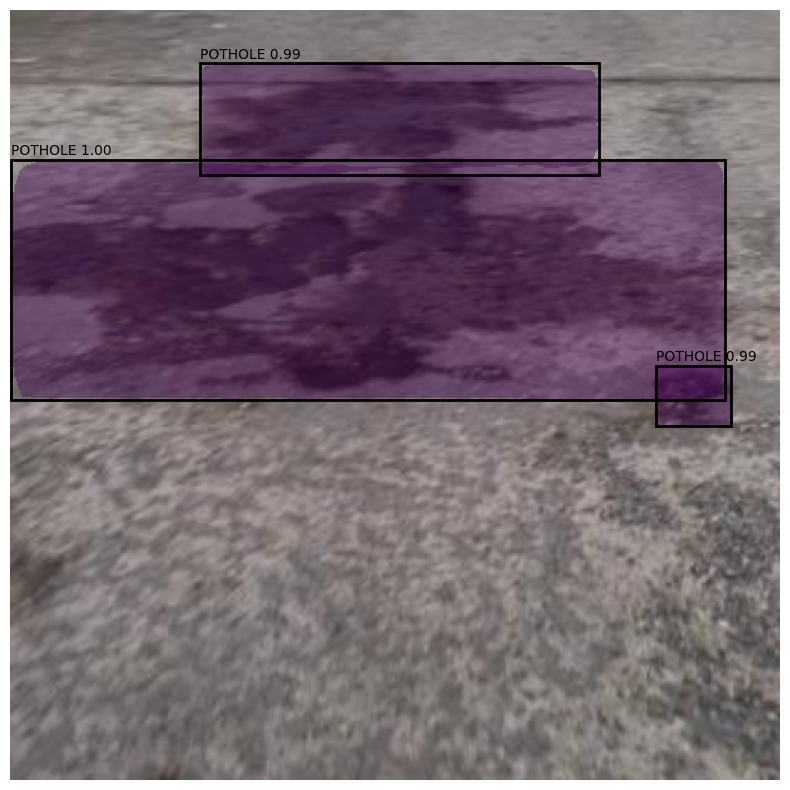

In [35]:
run_preview("best")

# **6. PREDICTION ON EXTERNAL IMAGES**

In [ ]:
model_path = "/content/drive/MyDrive/Colab Notebooks/Pothole_detection_CV_Project/models/best.pth"
CLASS_NAMES = ["__background__", "pothole"]
LABEL_MAP = {1: "Pothole"}

def build_model(num_classes: int, min_size=400, max_size=640):
    """Build the Mask R-CNN the same way you trained it (min/max size can be adjusted)."""
    try:
        model = maskrcnn_resnet50_fpn_v2(weights="DEFAULT",
                                         min_size=min_size, max_size=max_size)
        print("[INFO] Loaded COCO-pretrained backbone weights.")
    except Exception:
        model = maskrcnn_resnet50_fpn_v2(weights=None,
                                         min_size=min_size, max_size=max_size)
        print("[WARN] Using random backbone weights (no internet).")
    # replace heads
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model

def load_weights(model, ckpt_path: str, device: torch.device):
    """Load either a plain state_dict or a resume checkpoint dict."""
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and "model_state" in state:
        model.load_state_dict(state["model_state"])
        print(f"[INFO] Loaded checkpoint bundle: {ckpt_path}")
    else:
        model.load_state_dict(state)
        print(f"[INFO] Loaded state_dict: {ckpt_path}")
    return model

def visualize_and_save(img_tensor, output, score_thresh=0.5, save_path=None):
    """Draw boxes/masks on the image."""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)

    boxes  = output.get("boxes",  torch.empty((0,4))).cpu().numpy()
    labels = output.get("labels", torch.empty((0,), dtype=torch.int64)).cpu().numpy()
    scores = output.get("scores", torch.empty((0,), dtype=torch.float32)).cpu().numpy()
    masks  = output.get("masks",  None)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    for i in range(len(boxes)):
        if i < len(scores) and scores[i] < score_thresh:
            continue
        x1, y1, x2, y2 = boxes[i].astype(int)
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               fill=False, linewidth=2, edgecolor="red"))
        lbl = LABEL_MAP.get(int(labels[i]), f"id_{int(labels[i])}") if i < len(labels) else "id_?"
        sc  = scores[i] if i < len(scores) else 1.0
        ax.text(x1, max(0, y1 - 5), f"{lbl} {sc:.2f}",
                color="yellow", bbox=dict(facecolor="black", alpha=0.5, pad=2), fontsize=10)
        if masks is not None and i < masks.shape[0]:
            m = (masks[i, 0].cpu().numpy() > 0.5).astype(np.uint8)
            ax.imshow(np.ma.masked_where(m == 0, m), alpha=0.4, cmap="jet")
    ax.axis("off")
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()



def predict_image(img,
                  checkpoint_path: str,
                  score_thresh: float = 0.5,
                  min_size: int = 750,
                  max_size: int = 750,
                  save_vis: str | None = "predictions/out.jpg",
                  save_json: str | None = "predictions/out.json"):
    """
    Run inference on one image and optionally save an annotated image and JSON.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = build_model(num_classes=len(CLASS_NAMES), min_size=min_size, max_size=max_size).to(device)
    load_weights(model, checkpoint_path, device)
    model.eval()

    # load image
    img_t = F.to_tensor(img).to(device)

    with torch.no_grad():
        output = model([img_t])[0]  # dict of boxes, labels, scores, masks
        print(output)

    # Filter by score_thresh for JSON too
    boxes  = output["boxes"].cpu().numpy().tolist()
    labels = output["labels"].cpu().numpy().tolist()
    scores = output["scores"].cpu().numpy().tolist()
    keep = [i for i, s in enumerate(scores) if s >= score_thresh]

    result = []
    for i in keep:
        result.append({
            "box": [float(x) for x in boxes[i]],  # [x1,y1,x2,y2]
            "label_id": int(labels[i]),
            "label": LABEL_MAP.get(int(labels[i]), str(labels[i])),
            "score": float(scores[i]),
        })

    # Save JSON
    if save_json:
        Path(save_json).parent.mkdir(parents=True, exist_ok=True)
        with open(save_json, "w", encoding="utf-8") as f:
            json.dump({"image": str(image_path), "detections": result}, f, indent=2)
        print(f"[INFO] Saved JSON to: {save_json}")

    # Visualize & save
    visualize_and_save(img_t.cpu(), output, score_thresh=score_thresh, save_path=save_vis)

    return result




[INFO] Loaded COCO-pretrained backbone weights.
[INFO] Loaded checkpoint bundle: /content/drive/MyDrive/Colab Notebooks/Pothole_detection_CV_Project/models/best.pth
{'boxes': tensor([[  0.6380,  48.6872, 199.6675, 112.3849],
        [ 62.0752,  21.9650, 196.4998,  51.5858],
        [145.2031, 104.8729, 177.5528, 121.5256],
        [  2.6929, 106.6626, 296.4478, 298.9066]]), 'labels': tensor([1, 1, 1, 1]), 'scores': tensor([0.9932, 0.9474, 0.3756, 0.1677]), 'masks': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0

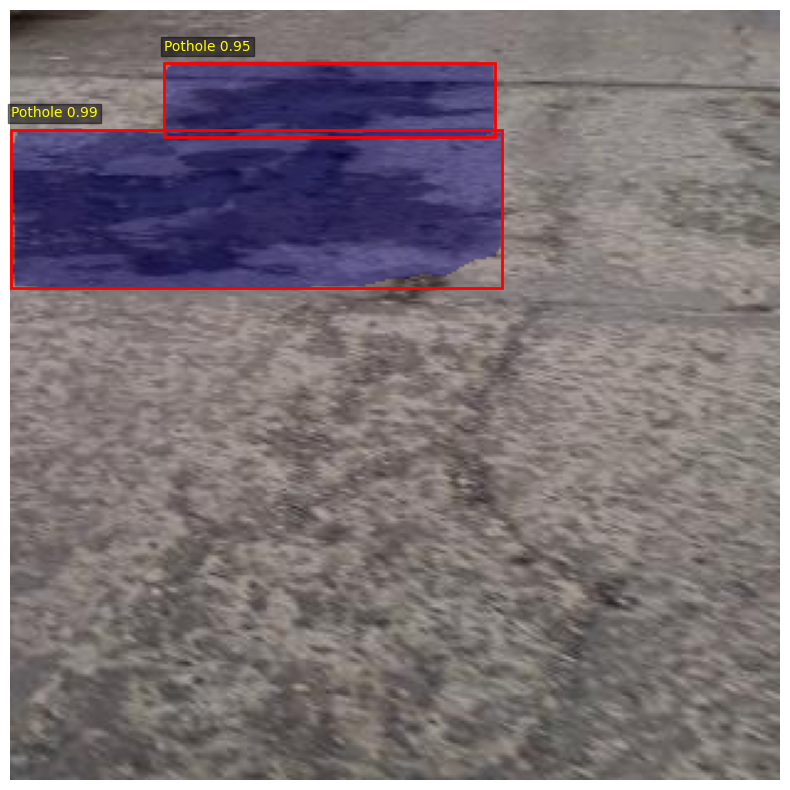

In [ ]:
image_path="/content/127.jpg"
img = Image.open(image_path).convert("RGB")

result = predict_image(
     img,
     checkpoint_path=model_path,
     score_thresh=0.5,
     save_vis="/content/img-18_rrr.jpg",
     save_json="/content/test_preds.json"
 )

# **7. PREDICTION ON EXTERNAL VIDEOS**

In [ ]:
@torch.inference_mode()
def predict_video(
    video_path,
    model,
    device,
    output_path="output_video.mp4",
    score_thresh=0.5,
    resize_to=512,
    label_map={1: "Pothole"},
    mask_alpha=0.4,
    show_progress=True,
    frame_step=10,
):

    model.to(device).eval()

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )

    frame_idx = 0
    start_time = time.time()

    print(f"[INFO] Processing video '{video_path}' ({total_frames} frames)...")

    while True:
        # ----------------------------------------------------
        # READ ONLY THE FRAMES YOU WANT TO PROCESS
        # ----------------------------------------------------
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1

        # skip frames: only process when hitting step
        if (frame_idx - 1) % frame_step != 0:
            continue
        # ----------------------------------------------------

        # Convert to RGB
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        h, w = rgb.shape[:2]

        # Resize & pad
        scale = resize_to / max(h, w)
        new_h, new_w = int(h * scale), int(w * scale)
        resized = cv2.resize(rgb, (new_w, new_h))
        pad_top, pad_left = 0, 0
        pad_bottom, pad_right = resize_to - new_h, resize_to - new_w
        rgb_padded = cv2.copyMakeBorder(
            resized, pad_top, pad_bottom, pad_left, pad_right,
            cv2.BORDER_CONSTANT, value=(0, 0, 0)
        )

        img_t = F.to_tensor(rgb_padded).unsqueeze(0).to(device)

        # Inference
        outputs = model(img_t)[0]
        boxes = outputs["boxes"].detach().cpu().numpy()
        scores = outputs["scores"].detach().cpu().numpy()
        labels = outputs["labels"].detach().cpu().numpy()
        masks = outputs.get("masks")

        if masks is not None:
            masks = masks.detach().cpu().numpy()[:, 0, :, :]

        # Draw detections
        overlay = frame.copy()
        for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
            if score < score_thresh:
                continue

            x1, y1, x2, y2 = box
            x1 -= pad_left; x2 -= pad_left
            y1 -= pad_top;  y2 -= pad_top
            x1 /= scale;    x2 /= scale
            y1 /= scale;    y2 /= scale
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w - 1, x2), min(h - 1, y2)

            label_text = f"{label_map.get(int(label), 'unknown')} {score:.2f}"

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(frame, label_text, (x1, max(25, y1 - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

            if masks is not None and i < len(masks):
                mask = masks[i]
                mask = cv2.resize(mask, (resize_to, resize_to))
                mask = mask[pad_top:pad_top+new_h, pad_left:pad_left+new_w]
                mask = cv2.resize(mask, (w, h))
                mask = (mask > 0.5).astype(np.uint8)

                color = np.array([0, 0, 255], dtype=np.uint8)
                colored_mask = np.zeros_like(frame, dtype=np.uint8)
                colored_mask[mask == 1] = color

                frame = cv2.addWeighted(colored_mask, mask_alpha, frame, 1 - mask_alpha, 0)

        out.write(frame)

        '''if show_progress and frame_idx % 10 == 0:'''
        torch.cuda.synchronize() if device == "cuda" else None
        elapsed = time.time() - start_time
        fps_current = frame_idx / elapsed
        print(f"[INFO] Frame {frame_idx}/{total_frames} ({fps_current:.2f} FPS)")

    cap.release()
    out.release()
    total_time = time.time() - start_time
    print(f"[INFO] Saved annotated video to {output_path}")
    print(f"[INFO] Average FPS: {frame_idx / total_time:.2f}")


In [ ]:
model = build_model(num_classes=len(CLASS_NAMES), min_size=512, max_size=512)
load_weights(model, model_path, device)

# Run detection
predict_video(
    video_path="/content/drive/MyDrive/Colab Notebooks/Pothole_detection_CV_Project/data/cut and join.webm",
    model=model,
    device=device,
    output_path="/content/pothole_result.mp4",
    score_thresh=0.8
)

[INFO] Loaded COCO-pretrained backbone weights.
[INFO] Loaded checkpoint bundle: /content/drive/MyDrive/Colab Notebooks/Pothole_detection_CV_Project/models/best.pth
[INFO] Processing video '/content/drive/MyDrive/Colab Notebooks/Pothole_detection_CV_Project/data/cut and join.webm' (2454 frames)...
[INFO] Frame 1/2454 (0.10 FPS)
[INFO] Frame 11/2454 (0.55 FPS)
[INFO] Frame 21/2454 (0.71 FPS)
[INFO] Frame 31/2454 (0.82 FPS)
[INFO] Frame 41/2454 (0.86 FPS)
[INFO] Frame 51/2454 (0.89 FPS)
[INFO] Frame 61/2454 (0.93 FPS)
[INFO] Frame 71/2454 (0.94 FPS)
[INFO] Frame 81/2454 (0.94 FPS)
[INFO] Frame 91/2454 (0.97 FPS)
[INFO] Frame 101/2454 (0.97 FPS)
[INFO] Frame 111/2454 (0.98 FPS)
[INFO] Frame 121/2454 (0.99 FPS)
[INFO] Frame 131/2454 (0.99 FPS)
[INFO] Frame 141/2454 (1.00 FPS)
[INFO] Frame 151/2454 (1.01 FPS)
[INFO] Frame 161/2454 (1.01 FPS)
[INFO] Frame 171/2454 (1.01 FPS)
[INFO] Frame 181/2454 (1.02 FPS)
[INFO] Frame 191/2454 (1.02 FPS)
[INFO] Frame 201/2454 (1.02 FPS)
[INFO] Frame 211/24